In [1]:
import numpy as np
import numpy as np
import torch
import sys, os
sys.path.append(os.path.abspath(".."))  # project root
print(os.path.abspath(".."))
from datasets.data import SpatialDataset
from datasets.transformerRegressorDataClass import TransformerPointDataset, collate_point_batches
from torch.utils.data import DataLoader
#from datasets.dt2_data import load_dt2_data
from models.transformerRegressor import TransformerCLSRegressor
import numpy as np
import matplotlib.pyplot as plt
from argument_transformer import parse_opt

/home/user_116/Project-B-Technion/Transformer_Map_Interp


In [2]:
@torch.no_grad()
def evaluate_split(model, dataset, trainset, device):
    ds = TransformerPointDataset(dataset, trainset, device=device)
    loader = DataLoader(ds, batch_size=32, shuffle=False, collate_fn=collate_point_batches)

    preds, trues, coords = [], [], []
    y_mean, y_std = trainset.y_mean.to(device), trainset.y_std.to(device)

    model.eval()
    for mem, mask, y, cls_coord in loader:
        mem, mask, y = mem.to(device), mask.to(device), y.to(device)
        y_hat = model(mem, mask)

        # denormalize
        y_hat_real = y_hat * y_std + y_mean
        y_real = y * y_std + y_mean

        preds.append(y_hat_real.cpu())
        trues.append(y_real.cpu())
        coords.append(cls_coord.cpu())

    preds = torch.cat(preds)
    trues = torch.cat(trues)
    coords = torch.cat(coords)

    abs_err = torch.abs(preds - trues)
    return coords, abs_err


def plot_error_map(coords, errors, title="Error map", cmap="inferno"):
    plt.figure(figsize=(10,8))
    sc = plt.scatter(coords[:,1], coords[:,0], c=errors, s=6, cmap=cmap)
    plt.colorbar(sc, label="Absolute Error (m)")
    plt.xlabel("Longitude"); plt.ylabel("Latitude")
    plt.title(title)
    plt.show()

In [3]:
# Show the current working directory
from pathlib import Path
print(os.getcwd())
os.chdir("..")
sys.path.append(os.path.abspath(".."))  # project root
print(os.path.abspath(".."))
p_cache = Path("cache")
print("cache exists?", p_cache.exists(), "->", p_cache.resolve())

trainset = torch.load(r"./cache/trainset_blobed.pt",map_location="cpu",weights_only=False)
validset = torch.load(r"./cache/validset_blobed.pt",map_location="cpu",weights_only=False)
testset = torch.load(r"./cache/testset_blobed.pt",map_location="cpu",weights_only=False)

/home/user_116/Project-B-Technion/Transformer_Map_Interp/display
/home/user_116/Project-B-Technion
cache exists? True -> /home/user_116/Project-B-Technion/Transformer_Map_Interp/cache


In [4]:
avg_size = sum(len(inner) for inner in validset.obs_coords_norm) / len(validset.obs_coords_norm)
print(f"Number of neighbors at Val set: {avg_size}")

avg_size = sum(len(inner) for inner in testset.obs_coords_norm) / len(testset.obs_coords_norm)
print(f"Number of neighbors at Test set: {avg_size}")

avg_size = sum(len(inner) for inner in trainset.obs_coords_norm) / len(trainset.obs_coords_norm)
print(f"Number of neighbors at Train set:{avg_size}")

print(trainset.y_std.detach().cpu().numpy())
print(trainset.y_mean.detach().cpu().numpy())
print(len(trainset.obs_y))
print(len(validset.obs_y))
print(len(testset.obs_y))

Number of neighbors at Val set: 10.0
Number of neighbors at Test set: 10.0
Number of neighbors at Train set:10.0
463.7793
599.98444
5905797
95315
99025


In [5]:
import argparse
import torch
argv_bak = sys.argv
try:
    sys.argv = [argv_bak[0]]  # keep program name only; drop Jupyter’s flags
    args = parse_opt()
finally:
    sys.argv = argv_bak
args.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
args.dropout = 0.0
args.model = "transformer"
in_dim = 3  # [Δlat, Δlon, y_known_norm, is_observed] # Orit 12.10 from 4 --> 3
print("Using device:", args.device)
model = TransformerCLSRegressor(
    in_dim=in_dim,
    d_model=args.d_model,
    nhead=args.n_heads,       # keep your arg names as-is
    num_layers=args.n_layers, # keep your arg names as-is
    dim_feedforward=args.ffn_dim,
    dropout=args.dropout,
    #cls_init=args.cls_init,
    use_posenc=args.use_posenc,
).to(args.device)
print("Model initialized:")
print(model)
#os.chdir("..")
sys.path.append(os.path.abspath("../"))  # project root
print(os.path.abspath("../"))
print("Current working directory:", os.getcwd())
print("File exists?", os.path.exists("../saved_models/For_Submission/best_model_epoch_35_batch_20000.pt"))
ckpt_path = f"../saved_models/For_Submission/best_model_epoch_35_batch_20000.pt"
last_path = f"../saved_models/For_Submission/last_epoch_model.pt"
print(f"Loading checkpoint from {ckpt_path}")
model.load_state_dict(torch.load(last_path, map_location=args.device))

device: cuda
Using device: cuda
Model initialized:
TransformerCLSRegressor(
  (in_proj): Linear(in_features=3, out_features=256, bias=True)
  (decoder): TransformerDecoder(
    (layers): ModuleList(
      (0-15): 16 x TransformerDecoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (multihead_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=256, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
        (linear2): Linear(in_features=256, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm3): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.0, inplace=F

<All keys matched successfully>

In [6]:
@torch.no_grad()
def predict(dataset, trainset):
    ds = TransformerPointDataset(dataset, trainset, device=args.device)
    loader = DataLoader(ds, batch_size=64, shuffle=False, collate_fn=collate_point_batches)
    preds, trues, coords = [], [], []

    for mem, y, cls_coords in loader:
        mem = mem.to(args.device)
        y_hat = model(mem)
        y_hat_real = y_hat * trainset.y_std + trainset.y_mean
        y_real = y * trainset.y_std + trainset.y_mean
        preds.append(y_hat_real.cpu())
        trues.append(y_real.cpu())
        coords.append(cls_coords.cpu())

    preds = torch.cat(preds).numpy()
    trues = torch.cat(trues).numpy()
    coords = torch.cat(coords).numpy()
    errors = preds - trues
    return coords, trues, preds, errors


In [7]:
from matplotlib.colors import Normalize, TwoSlopeNorm

val_coords, val_true, val_pred, val_err = predict(validset, trainset)
test_coords, test_true, test_pred, test_err = predict(testset, trainset)


# 1) Elevation uses the SAME vmin/vmax across val+test
elev_min = float(min(val_true.min(), test_true.min()))
elev_max = float(max(val_true.max(), test_true.max()))
elev_norm = Normalize(vmin=elev_min, vmax=elev_max)

# 2) Error uses a symmetric scale around 0, shared across val+test
err_abs_max = float(np.max(np.abs(np.concatenate([val_err.ravel(), test_err.ravel()]))))
err_norm = TwoSlopeNorm(vmin=-err_abs_max, vcenter=0.0, vmax=err_abs_max)

In [59]:
def plot_error_map(coords, true, err, title_prefix,
                   cmap_elev="terrain", cmap_err="coolwarm",
                   elev_norm=None, err_norm=None, save_name=None):
    lons, lats = coords[:,1], coords[:,0]
    fig, axs = plt.subplots(2, 1, figsize=(9, 12), constrained_layout=True)

    # Top: original elevation (shared color scale)
    sc1 = axs[0].scatter(lons, lats, c=true, cmap=cmap_elev, s=6, norm=elev_norm)
    axs[0].set_title(f"{title_prefix} – Original Elevation")
    axs[0].set_xlabel("Longitude"); axs[0].set_ylabel("Latitude")
    plt.colorbar(sc1, ax=axs[0], label="Elevation (m)")

    # Bottom: error (shared, centered at 0)
    sc2 = axs[1].scatter(lons, lats, c=err, cmap=cmap_err, s=20, norm=err_norm)
    axs[1].set_title(f"{title_prefix} – Prediction Error (Pred - True)")
    axs[1].set_xlabel("Longitude"); axs[1].set_ylabel("Latitude")
    plt.colorbar(sc2, ax=axs[1], label="Error (m)")

    if save_name:
        plt.savefig(save_name, dpi=300, bbox_inches="tight")
    plt.show()


In [67]:
def plot_error_map(coords_all, true_all,
                   coords_sel, true_sel, err_sel,
                   title_prefix,
                   cmap_elev="gray", cmap_err="coolwarm",
                   elev_norm=None, err_norm=None,
                   save_name=None):

    # --- full map (context) ---
    lons_all, lats_all = coords_all[:,1], coords_all[:,0]

    # --- selected subset ---
    lons_sel, lats_sel = coords_sel[:,1], coords_sel[:,0]

    fig, axs = plt.subplots(1, 1, figsize=(9, 12), constrained_layout=True)

    # ======================================================
    # TOP: Elevation map (context + highlighted subset)
    # ======================================================
    axs.scatter(
        lons_all, lats_all,
        c="gray",
        s=4,
        alpha=0.4,
        linewidths=0,
        norm = elev_norm
    )

    sc1 = axs.scatter(
        lons_sel, lats_sel,
        c=true_sel,
        cmap="terrain",      # or gray if you prefer
        s=18,
        alpha=0.9,
        norm=elev_norm
    )

    axs.set_title(f"{title_prefix} – Elevation (highlighted subset)")
    axs.set_xlabel("Longitude")
    axs.set_ylabel("Latitude")
    plt.colorbar(sc1, ax=axs, label="Elevation (m)")

    # ======================================================
    # BOTTOM: Error map (context + highlighted subset)
    # ======================================================
    # axs[1].scatter(
    #     lons_all, lats_all,
    #     c="lightgray",
    #     s=4,
    #     alpha=0.4,
    #     linewidths=0
    # )

    # sc2 = axs[1].scatter(
    #     lons_sel, lats_sel,
    #     c=err_sel,
    #     cmap=cmap_err,
    #     s=18,
    #     alpha=0.9,
    #     norm=err_norm
    # )

    # axs[1].set_title(f"{title_prefix} – Prediction Error (Pred − True)")
    # axs[1].set_xlabel("Longitude")
    # axs[1].set_ylabel("Latitude")
    # plt.colorbar(sc2, ax=axs[1], label="Error (m)")

    # ======================================================
    # Cosmetic cleanup
    # ======================================================

    axs.set_aspect("equal", adjustable="box")

    if save_name:
        plt.savefig(save_name, dpi=300, bbox_inches="tight")

    plt.show()


In [75]:
def plot_error_map(coords_all, true_all,
                   coords_sel, true_sel, err_sel,
                   title_prefix,
                   cmap_err="coolwarm",
                   elev_norm=None, err_norm=None,
                   save_name=None):

    lons_all, lats_all = coords_all[:,1], coords_all[:,0]
    lons_sel, lats_sel = coords_sel[:,1], coords_sel[:,0]

    fig, ax = plt.subplots(1, 1, figsize=(9, 12), constrained_layout=True)

    # === Background: grayscale terrain ===
    sc_gray = ax.scatter(
        lons_all, lats_all,
        c=true_all,
        cmap="gray",
        norm=elev_norm,
        s=4,
        alpha=0.35,
        linewidths=0
    )

    # === Highlighted subset: colored terrain ===
    sc = ax.scatter(
        lons_sel, lats_sel,
        c=true_sel,
        cmap="terrain",
        norm=elev_norm,
        s=18,
        alpha=0.95
    )
    plt.colorbar(sc_gray, ax=ax, label="Elevation (m)")
    ax.set_title(f"{title_prefix} – Elevation (highlighted subset)")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_aspect("equal", adjustable="box")
    plt.colorbar(sc, ax=ax, label="Elevation (m)")
    

    if save_name:
        plt.savefig(save_name, dpi=300, bbox_inches="tight")

    plt.show()

[[ 3.4693563 ]
 [ 0.0604071 ]
 [-0.84519607]
 ...
 [-0.44845563]
 [ 0.1703732 ]
 [ 0.6231748 ]]
[[ 3.4693563 ]
 [ 0.0604071 ]
 [-0.84519607]
 ...
 [-0.44845563]
 [ 0.1703732 ]
 [ 0.6231748 ]]


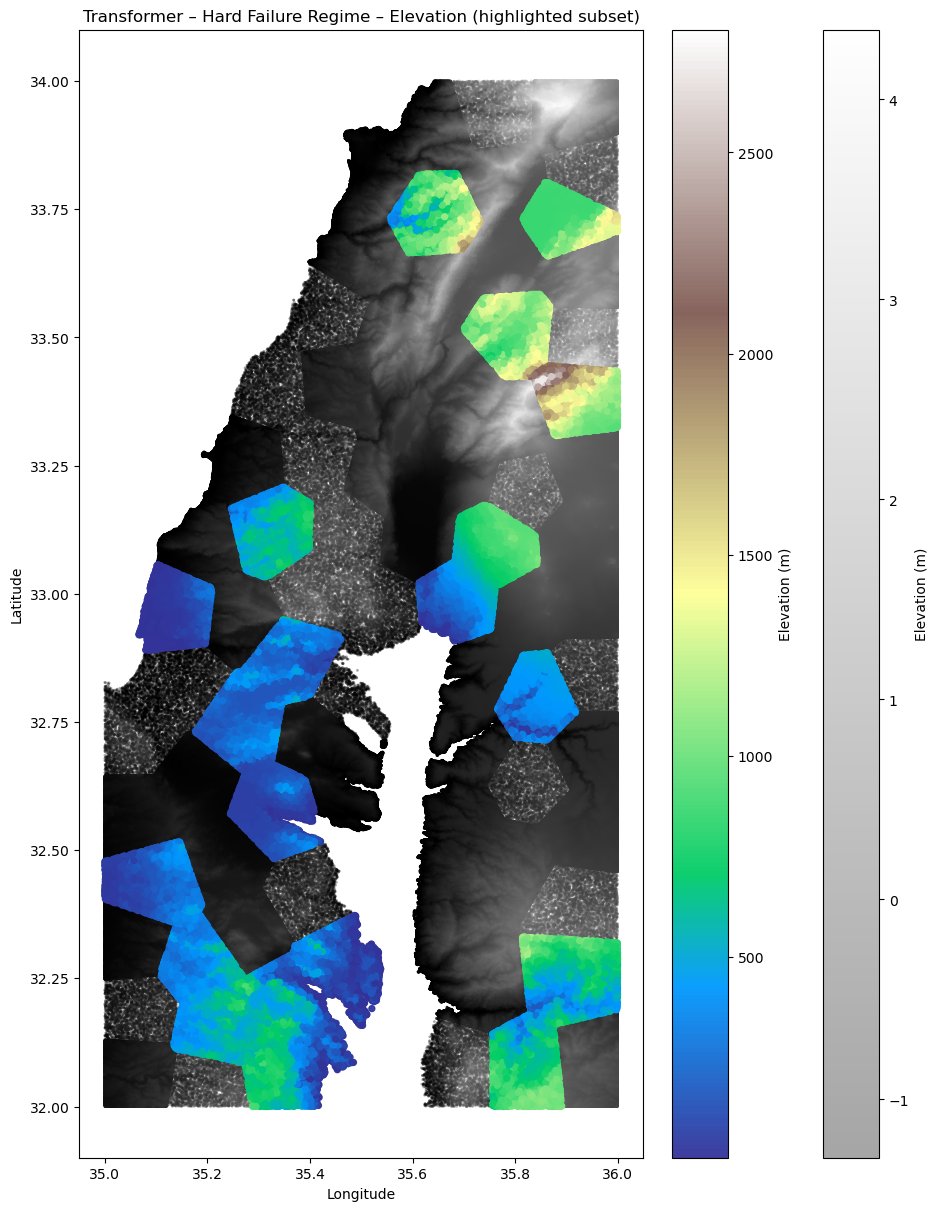

In [76]:
# full test set (context) - concat trainset + validset
coords_all = np.concatenate([trainset.coords.cpu().numpy(), validset.coords.cpu().numpy()], axis=0)
true_all   = np.concatenate([(trainset.y.cpu().numpy() - trainset.y_mean.cpu().numpy())/trainset.y_std.cpu().numpy(),
                             (validset.y.cpu().numpy() - trainset.y_mean.cpu().numpy())/trainset.y_std.cpu().numpy()], axis=0)
#true_all_unormed = np.concatenate([trainset.y.cpu().numpy(),
print(true_all)
# coords_all = trainset.coords.cpu().numpy() 
# true_all   = (trainset.y.cpu().numpy())#- trainset.y_mean.cpu().numpy())/trainset.y_std.cpu().numpy()
print(true_all)
# selected subset (e.g. top 10% hardest or transformer-best)
coords_sel = testset.coords.cpu().numpy()
true_sel   = testset.y.cpu().numpy()
err_sel    = test_err
plot_error_map(
    coords_all, true_all,
    coords_sel, true_sel, err_sel,
    title_prefix="Transformer – Hard Failure Regime",
    err_norm=elev_norm,
)


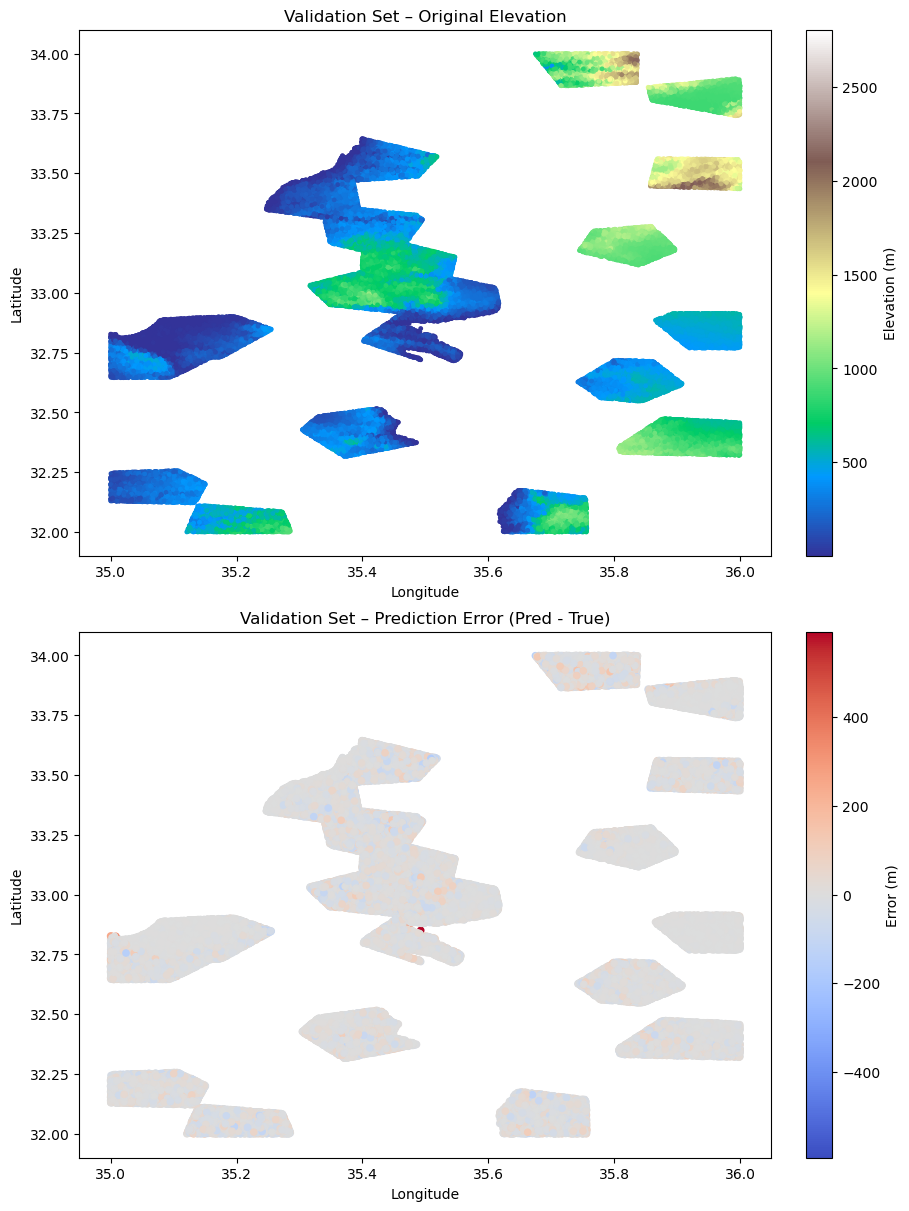

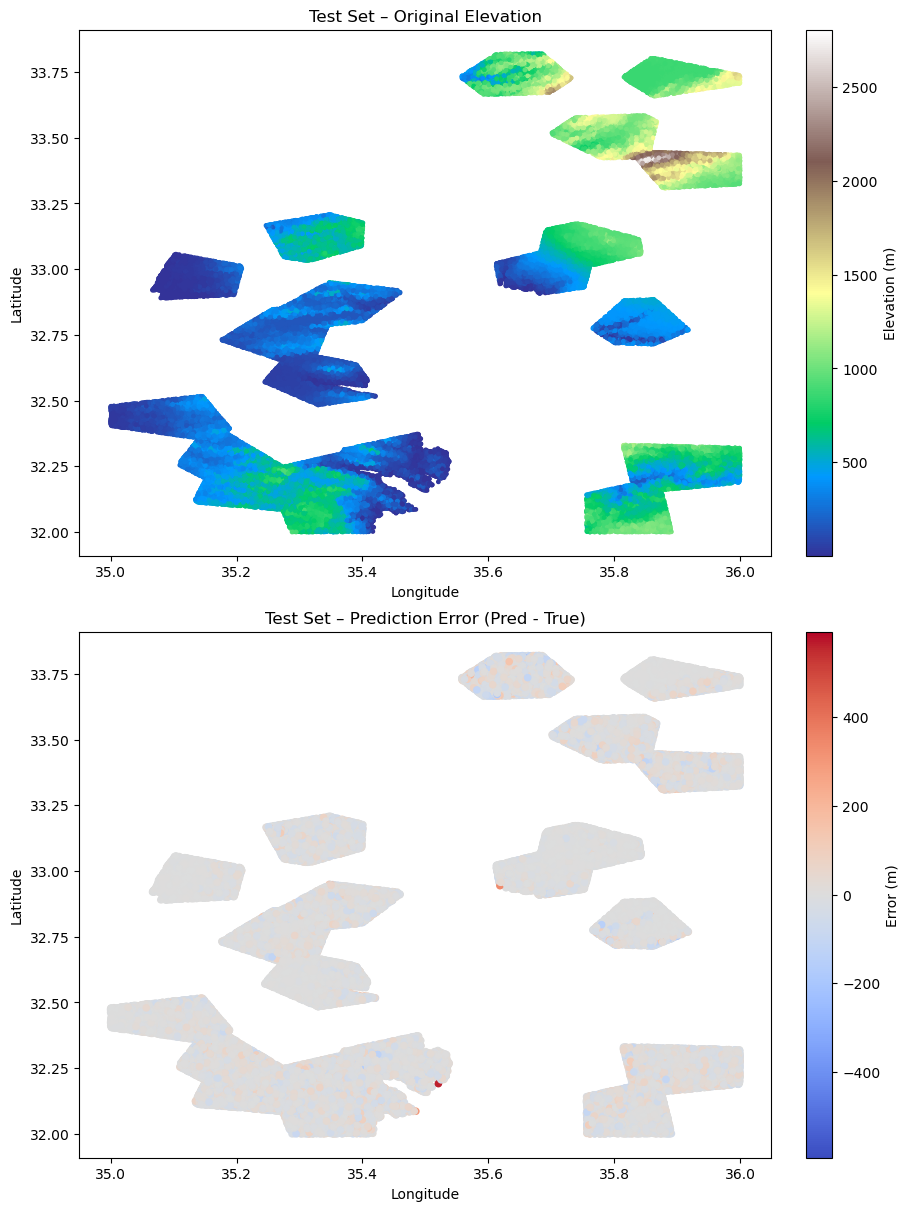

In [39]:
plot_error_map(val_coords,  val_true,  val_err,  "Validation Set",
               elev_norm=elev_norm, err_norm=err_norm, save_name="val_error_map.png")

plot_error_map(test_coords, test_true, test_err, "Test Set",
               elev_norm=elev_norm, err_norm=err_norm, save_name="test_error_map.png")

In [8]:
from scipy.interpolate import LinearNDInterpolator
def _to_numpy(x):
    # works for numpy, torch tensors, lists
    if hasattr(x, "detach"):  # torch.Tensor
        return x.detach().cpu().numpy()
    return np.asarray(x)

def _scalar(x):
    if x is None:
        return np.nan
    a = np.asarray(x)
    if a.size == 0:
        return np.nan
    # robustly take the first element (handles (), (1,), (1,1), etc.)
    return float(a.ravel()[0])


def idw_local_all(nei_coords_list, nei_y_list, query_coords, p=2.0, eps=1e-12):
    """
    Local IDW using *all* precomputed neighbors for each target point.
    """
    N = len(nei_coords_list)
    preds = np.zeros(N, dtype=float)
    qxy = _to_numpy(query_coords)

    for i in range(N):
        nei_xy = _to_numpy(nei_coords_list[i]).astype(float)
        nei_y  = _to_numpy(nei_y_list[i]).astype(float).reshape(-1)
        #print(nei_xy.size)
        if nei_xy.size == 0:
            preds[i] = np.nan
            continue

        d = np.linalg.norm(nei_xy - qxy[i], axis=1)  # (S,)

        # exact match protection
        if np.any(d < 1e-12):
            preds[i] = float(nei_y[d.argmin()])
            continue

        w = 1.0 / (d**p + eps)
        preds[i] = float(np.sum(w * nei_y) / np.sum(w))

    return preds

def linear_local(nei_coords_list, nei_y_list, query_coords, fill_with_idw=True, p=2.0):
    """
    Local linear interpolation using precomputed neighbors.
    - nei_coords_list: list of (S_i, 2)
    - nei_y_list: list of (S_i,)
    - query_coords: (N, 2)
    - fill_with_idw: if True, fill NaN/extrapolation with local IDW
    """
    N = len(nei_coords_list)
    preds = np.zeros(N, dtype=float)
    qxy = _to_numpy(query_coords)
    counter_NaN=0
    for i in range(N):
        nei_xy = _to_numpy(nei_coords_list[i]).astype(float)
        nei_y  = _to_numpy(nei_y_list[i]).astype(float).reshape(-1)

        if len(nei_xy) < 3:
            # not enough points to form a triangle; fallback to mean
            preds[i] = np.mean(nei_y)
            continue

        try:
            interp = LinearNDInterpolator(nei_xy, nei_y, fill_value=np.nan)
            pred = interp(qxy[i])
            
            if np.isnan(pred) and fill_with_idw:
                #print("NaN")
                counter_NaN+=1
                print(f"Total NaN so far: {counter_NaN}")
                # fallback to local IDW if outside convex hull
                # d = np.linalg.norm(nei_xy - qxy[i], axis=1)
                # w = 1.0 / (d**p + 1e-12)
                # pred = np.sum(w * nei_y) / np.sum(w)
                d = np.linalg.norm(nei_xy - qxy[i], axis=1)
                w = 1.0 / (d**p + 1e-12)
                pred = np.sum(w * nei_y) / np.sum(w)
        except Exception:
             # triangulation sometimes fails if neighbors are colinear
             d = np.linalg.norm(nei_xy - qxy[i], axis=1)
             w = 1.0 / (d**p + 1e-12)
             pred = np.sum(w * nei_y) / np.sum(w)

        preds[i] = _scalar(pred)
        print(f"Total NaN: {counter_NaN}")
    return preds

def rbf_local(nei_coords_list, nei_y_list, query_coords, function='linear'):
    preds = np.zeros(len(nei_coords_list))
    qxy = _to_numpy(query_coords)
    for i, (xy, y) in enumerate(zip(nei_coords_list, nei_y_list)):
        xy = _to_numpy(xy); y = _to_numpy(y).reshape(-1)
        if len(xy) < 3:
            preds[i] = np.mean(y)
            continue
        try:
            rbf = Rbf(xy[:,0], xy[:,1], y, function=function)
            preds[i] = float(rbf(qxy[i,0], qxy[i,1]))
        except Exception:
            preds[i] = np.mean(y)
    return preds

def MSE(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def MAP(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred))/len(y_true)

In [9]:
print("Performing Local IDW interpolation on validation and test sets...")
val_query_coords = torch.zeros_like(validset.query_coords)
test_query_coords = torch.zeros_like(testset.query_coords)
val_query_coords_normal = validset.query_coords
val_pred_classical = idw_local_all(validset.obs_coords_norm, validset.obs_y_norm, val_query_coords)
test_pred_classical = idw_local_all(testset.obs_coords_norm, testset.obs_y_norm,
                     test_query_coords)

Performing Local IDW interpolation on validation and test sets...


In [10]:
mse_val_classical = np.mean((val_pred_classical - validset.q_y_norm.detach().cpu().numpy())**2)
mae_val_classical = np.mean(np.abs(val_pred_classical - validset.q_y_norm.detach().cpu().numpy()))
mse_test_classical = np.mean((test_pred_classical - testset.q_y_norm.detach().cpu().numpy())**2)
mae_test_classical = np.mean(np.abs(test_pred_classical - testset.q_y_norm.detach().cpu().numpy()))
print(f"[Local IDW] Validation MSE={mse_val_classical:.5f}, MAE={mae_val_classical:.5f}")
print(f"[Local IDW] Test MSE={mse_test_classical:.5f}, MAE={mae_test_classical:.5f}")

[Local IDW] Validation MSE=0.00490, MAE=0.04506
[Local IDW] Test MSE=0.00511, MAE=0.04607


In [11]:
val_pred_unnorm_classical = val_pred_classical * trainset.y_std.detach().cpu().numpy() + trainset.y_mean.detach().cpu().numpy()
test_pred_unnorm_classical = test_pred_classical * trainset.y_std.detach().cpu().numpy() + trainset.y_mean.detach().cpu().numpy()
#val_true_unnorm = validset.query_y.detach().cpu().numpy() * trainset.y_std.detach().cpu().numpy() + trainset.y_mean.detach().cpu().numpy()
#test_true_unnorm = testset.query_y.detach().cpu().numpy() * trainset.y_std.detach().cpu().numpy() + trainset.y_mean.detach().cpu().numpy()
val_true_unnorm = validset.query_y.detach().cpu().numpy()
test_true_unnorm = testset.query_y.detach().cpu().numpy()
print(val_pred_unnorm_classical)
print(test_pred_unnorm_classical)
mse_val_classical = np.mean((val_pred_unnorm_classical -val_true_unnorm)**2)
print(validset.query_y)
mae_val_classical = np.mean(np.abs(val_pred_unnorm_classical - val_true_unnorm))
mse_test_classical = np.mean((test_pred_unnorm_classical -test_true_unnorm)**2)
mae_test_classical = np.mean(np.abs(test_pred_unnorm_classical - test_true_unnorm))
print(f"[Local IDW] Validation MSE={mse_val_classical:.3f}, MAE={mae_val_classical:.3f}")
print(f"[Local IDW] Test MSE={mse_test_classical:.3f}, MAE={mae_test_classical:.3f}")

[501.4571931  256.85243493 758.26403533 ... 398.58330372 681.49327535
 885.41314257]
[ 891.95586777  949.27425825   80.13947673 ... 1504.94607425   17.27716323
  242.63491002]
tensor([522., 259., 775.,  ..., 392., 679., 889.])
[Local IDW] Validation MSE=1054.432, MAE=20.900
[Local IDW] Test MSE=1098.741, MAE=21.367


In [ ]:
from matplotlib.colors import Normalize, TwoSlopeNorm

# -------------------------------------
# PICK QUERY SAMPLE
# -------------------------------------
#i = np.random.randint(len(testset))  # random query from test
test_err = test_pred - test_true
test_err_classical = test_pred_unnorm_classical - test_true_unnorm

vec= np.abs(test_err) - np.abs(test_err_classical)
indices = (np.abs(vec) < 5) 
better_learning_indices = np.where(indices)[0]
print("Number of better learning samples:", len(better_learning_indices))

vec= np.abs(test_err) - np.abs(test_err_classical)
indices = (vec > 5) 
better_learning_indices = np.where(indices)[0]
print("Number of better learning samples:", len(better_learning_indices))

vec= np.abs(test_err) - np.abs(test_err_classical)
indices = (vec < -5) 
better_learning_indices = np.where(indices)[0]
print("Number of better learning samples:", len(better_learning_indices))

print("----")

test_err = test_pred - test_true
test_err_classical = test_pred_unnorm_classical - test_true_unnorm

vec= np.abs(test_err) - np.abs(test_err_classical)
indices = (np.abs(vec) < 2) 
better_learning_indices = np.where(indices)[0]
print("Number of better learning samples:", len(better_learning_indices))

vec= np.abs(test_err) - np.abs(test_err_classical)
indices = (vec > 2) 
better_learning_indices = np.where(indices)[0]
print("Number of better learning samples:", len(better_learning_indices))

vec= np.abs(test_err) - np.abs(test_err_classical)
indices = (vec < -2) 
better_learning_indices = np.where(indices)[0]
print("Number of better learning samples:", len(better_learning_indices))
#indices =(np.abs(test_err) - np.abs(test_err_classical)) < 1 & (np.abs(test_err) - np.abs(test_err_classical) > 0)
# better_learning_indices = ((np.abs(test_err_classical) - np.abs(test_err)) > 10) & ((np.abs(test_err_classical) - np.abs(test_err)) > 0)
# better_learning_indices = np.where(better_learning_indices)[0]
#better_learning_indices = ((np.abs(test_err) - np.abs(test_err_classical)) < 0.1) & ((np.abs(test_err) - np.abs(test_err_classical)) > 0)
# print("Number of better learning samples:", len(better_learning_indices))
# vec= (np.abs(test_err) - np.abs(test_err_classical))

# Let's pick the 10% of the test samples where the transformer outperforms classical IDW the most
indices = np.argsort(np.abs(test_err_classical) - np.abs(test_err))[-int(0.1*len(test_err)):]
better_learning_indices = indices
# Lets compute the RMSE and the MAE for these samples
test_rmse_better = np.mean((test_err[better_learning_indices])**2)**0.5
test_mae_better = np.mean(np.abs(test_err[better_learning_indices]))
test_rmse_better_idw = np.mean((test_err_classical[better_learning_indices])**2)**0.5
test_mae_better_idw = np.mean(np.abs(test_err_classical[better_learning_indices]))
print(f"Transformer on better learning samples: RMSE={test_rmse_better:.3f}, MAE={test_mae_better:.3f}")
print(f"Classical IDW on better learning samples: RMSE={test_rmse_better_idw:.3f}, MAE={test_mae_better_idw:.3f}")
# Let's pick the 10% of the test samples where the classical IDW outperforms the transformer the most
indices = np.argsort(np.abs(test_err) - np.abs(test_err_classical))[-int(0.1*len(test_err)): ]
better_learning_indices = indices
# Lets compute the RMSE and the MAE for these samples
test_rmse_better_idw = np.mean((test_err_classical[better_learning_indices])**2)**0.5
test_mae_better_idw = np.mean(np.abs(test_err_classical[better_learning_indices]))
test_rmse_better = np.mean((test_err[better_learning_indices])**2)**0.5
test_mae_better = np.mean(np.abs(test_err[better_learning_indices]))
print(f"Classical IDW on better learning samples: RMSE={test_rmse_better_idw:.3f}, MAE={test_mae_better_idw:.3f}")
print(f"Transformer on better learning samples: RMSE={test_rmse_better:.3f}, MAE={test_mae_better:.3f}")

Number of better learning samples: 44373
Number of better learning samples: 22596
Number of better learning samples: 32056
----
Number of better learning samples: 23617
Number of better learning samples: 32762
Number of better learning samples: 42646
Transformer on better learning samples: RMSE=36.815, MAE=25.855
Classical IDW on better learning samples: RMSE=72.757, MAE=63.525
Classical IDW on better learning samples: RMSE=28.991, MAE=19.205
Transformer on better learning samples: RMSE=52.076, MAE=44.196


286.7787780761719
81895
254.23861694335938
241.00094614698992
tensor([[32.2890281677, 35.3573608398],
        [32.2968063354, 35.3659706116],
        [32.2956962585, 35.3598594666],
        [32.2948608398, 35.3559722900],
        [32.2956962585, 35.3584709167],
        [32.2795829773, 35.3601379395],
        [32.2954177856, 35.3612518311],
        [32.2954177856, 35.3584709167],
        [32.2962493896, 35.3620834351],
        [32.2909736633, 35.3531951904]])
tensor([285., 227., 218., 191., 197., 169., 226., 201., 215., 214.])
10
tensor([[[ 8.3541870117e-04, -5.8326721191e-03, -6.7916882038e-01],
         [ 8.6135864258e-03,  2.7770996094e-03, -8.0422830582e-01],
         [ 7.5035095215e-03, -3.3340454102e-03, -8.2363408804e-01],
         [ 6.6680908203e-03, -7.2212219238e-03, -8.8185143471e-01],
         [ 7.5035095215e-03, -4.7225952148e-03, -8.6891424656e-01],
         [-8.6097717285e-03, -3.0555725098e-03, -9.2928779125e-01],
         [ 7.2250366211e-03, -1.9416809082e-03, -8.063845

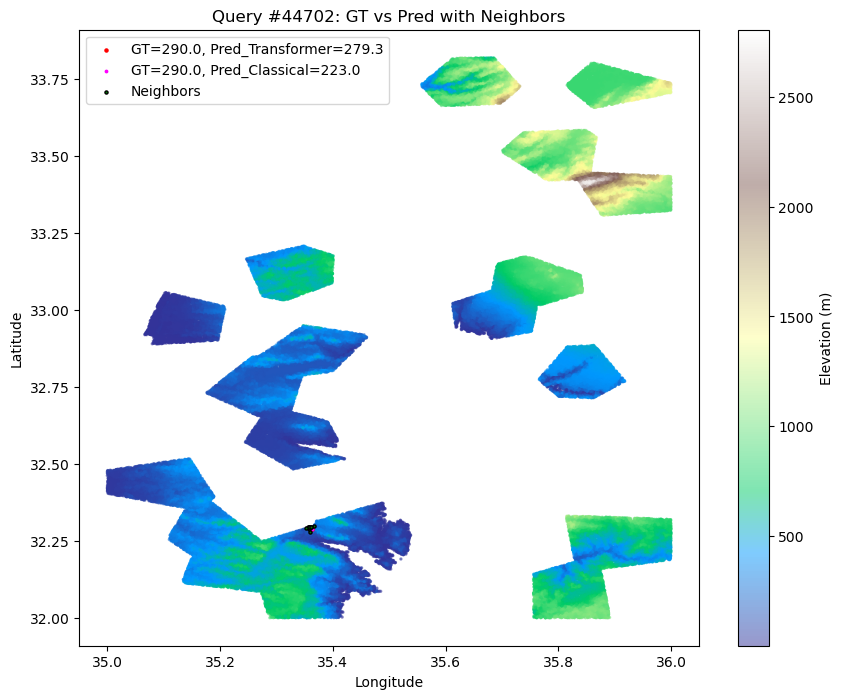

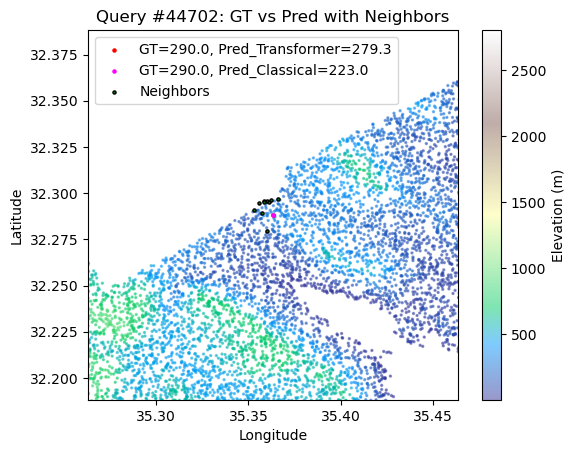

In [35]:
from matplotlib.colors import Normalize, TwoSlopeNorm

# -------------------------------------
# PICK QUERY SAMPLE
# -------------------------------------
#i = np.random.randint(len(testset))  # random query from test
test_err = test_pred - test_true
test_err_classical = test_pred_unnorm_classical - test_true_unnorm
best_classical_result = False
if best_classical_result:
    vec= np.abs(test_err) - np.abs(test_err_classical)
    print(np.argmax(vec))
    # better_learning_indices = vec > 0 # transformer_err > classical_err --> transformer worse
    # print("Number of best learning samples:", len(np.where(better_learning_indices)[0]))
    # print(np.max(vec[better_learning_indices]))
    # max_error_index = np.argmax(vec[better_learning_indices])
    # print(test_pred[max_error_index])
    # print(test_true[max_error_index])
    # print(vec[max_error_index])
    i = np.argmax(vec)
    #print(i)
else:
    vec= np.abs(test_err_classical) - np.abs(test_err)
    print(max(vec))
    print(np.argmax(vec))
    idx = np.argmax(vec)
    v_excluded = np.delete(vec, idx)
    print(max(v_excluded))
    idx = np.argmax(v_excluded)
    v_excluded = np.delete(v_excluded, idx)
    print(max(v_excluded))
    i = np.argmax(v_excluded) + 2
#indices =(np.abs(test_err) - np.abs(test_err_classical)) < 1 & (np.abs(test_err) - np.abs(test_err_classical) > 0)
# better_learning_indices = ((np.abs(test_err_classical) - np.abs(test_err)) > 10) & ((np.abs(test_err_classical) - np.abs(test_err)) > 0)
# better_learning_indices = np.where(better_learning_indices)[0]
#better_learning_indices = ((np.abs(test_err) - np.abs(test_err_classical)) < 0.1) & ((np.abs(test_err) - np.abs(test_err_classical)) > 0)
# print("Number of better learning samples:", len(better_learning_indices))
# vec= (np.abs(test_err) - np.abs(test_err_classical))
# better_learning_indices = ((np.abs(test_err) - np.abs(test_err_classical)) > 0) & ((np.abs(test_err) - np.abs(test_err_classical)) > 266)
# print("Number of less learning samples:", len(np.where(better_learning_indices)[0]))
# print(np.max(vec[better_learning_indices]))
# max_error_index = np.argmax(vec[better_learning_indices])
# i = max_error_index
# print(i)
i = 44702
q_coord = testset.query_coords[i]    # (lat, lon)
q_gt = testset.query_y[i].item()
obs_coords = testset.obs_coords[i]
print(obs_coords)
obs_y = testset.obs_y[i]
# print with more number after dots
# WHY ISNT THIS WORK ???

torch.set_printoptions(precision=10)
print(obs_y)
# print(obs_y)
# print(f"{obs_y.item():3f}")
device = 'cuda'

# -------------------------------------
# MODEL PREDICTION
# -------------------------------------
# normalize neighbor coords relative to query
obs_coords_norm = testset.obs_coords_norm[i] 
print(len(obs_coords_norm))
obs_y_norm = testset.obs_y_norm[i]
y_pred_classical = test_pred_classical[i]* trainset.y_std + trainset.y_mean
# normalize lat/lon by std
dlat = obs_coords_norm[:, 0] 
dlon = obs_coords_norm[:, 1] 

mem_tokens = torch.stack([dlat, dlon, obs_y_norm.squeeze(-1)], dim=-1).unsqueeze(0).to(device)
print(mem_tokens)
pad_mask = torch.zeros(mem_tokens.size(1), dtype=torch.bool, device=device).unsqueeze(0)

with torch.no_grad():
    y_pred_norm = model(mem_tokens, pad_mask)
y_pred = y_pred_norm * trainset.y_std + trainset.y_mean

print(f"\nQuery #{i}: GT={q_gt:.2f}  |  Pred_Transformer={y_pred.item():.2f} |  Pred_Classical_Interp={y_pred_classical.item():.2f}")

# -------------------------------------
# PLOT MAP + POINTS
# -------------------------------------
elev_min = float(min(trainset.y.min(), testset.y.min()))
elev_max = float(max(trainset.y.max(), testset.y.max()))
elev_norm = Normalize(vmin=elev_min, vmax=elev_max)

plt.figure(figsize=(10, 8))

# === ADD TEST SET POINTS ===
# sc = plt.scatter(trainset.coords[:, 1], trainset.coords[:, 0],
#                  c=trainset.y.squeeze(-1), norm=elev_norm, s=2, cmap="terrain", alpha=0.5)

plt.scatter(testset.coords[:, 1], testset.coords[:, 0],
            c=testset.y.squeeze(-1), norm=elev_norm, s=2, cmap="terrain", alpha=0.5)
plt.colorbar(label="Elevation (m)")
# plt.colorbar(sc, label="Elevation (m)")

# query GT and prediction
plt.scatter(q_coord[1], q_coord[0], c='red', s=5, edgecolors='red', label=f"GT={q_gt:.1f}, Pred_Transformer={y_pred.item():.1f}")
plt.scatter(q_coord[1], q_coord[0], c='magenta', s=3, edgecolors='magenta', label=f"GT={q_gt:.1f}, Pred_Classical={y_pred_classical.item():.1f}")
plt.scatter(obs_coords[:,1], obs_coords[:,0], c='green', s=5, edgecolors='k', label="Neighbors")
# plt.scatter(q_coord[1], q_coord[0], c='red', marker='x', s=100, label=f"Pred={y_pred.item():.1f}")

plt.title(f"Query #{i}: GT vs Pred with Neighbors")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.show()

# ZOOM IN
plt.figure()
lat_c, lon_c = float(q_coord[0]), float(q_coord[1])
plt.xlim(lon_c - 0.1, lon_c +0.1)
plt.ylim(lat_c - 0.1, lat_c + 0.1)
plt.scatter(testset.coords[:, 1], testset.coords[:, 0],
            c=testset.y.squeeze(-1), norm=elev_norm, s=2, cmap="terrain", alpha=0.5)
plt.colorbar(label="Elevation (m)")
# plt.colorbar(sc, label="Elevation (m)")

# query GT and prediction
plt.scatter(q_coord[1], q_coord[0], c='red', s=5, edgecolors='red', label=f"GT={q_gt:.1f}, Pred_Transformer={y_pred.item():.1f}")
plt.scatter(q_coord[1], q_coord[0], c='magenta', s=5, edgecolors='magenta', label=f"GT={q_gt:.1f}, Pred_Classical={y_pred_classical.item():.1f}")
plt.scatter(obs_coords[:,1], obs_coords[:,0], c='green', s=5, edgecolors='k', label="Neighbors")
# plt.scatter(q_coord[1], q_coord[0], c='red', marker='x', s=100, label=f"Pred={y_pred.item():.1f}")

plt.title(f"Query #{i}: GT vs Pred with Neighbors")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()

plt.gca().set_aspect('equal', adjustable='box')
plt.show()


Draw the what performs better, when similar is results that apart for some meters

[ 8.95586777 17.27425825  5.13947673 ...  1.94607425 10.72283677
  6.36508998]
[ 3.949829  19.294922   6.6967773 ... 12.859375   6.211731  13.342651 ]


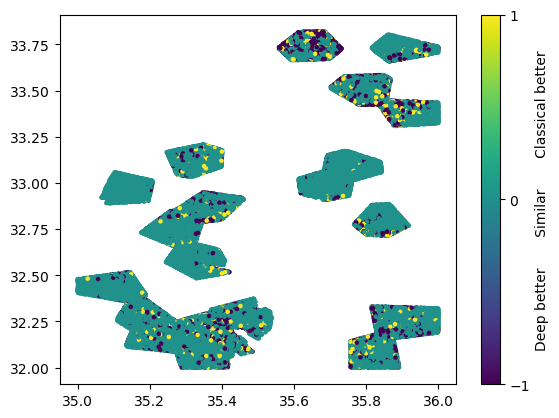

In [30]:
#err_classical = np.abs(test_pred_classical* trainset.y_std.detach().cpu().numpy() + trainset.y_mean.detach().cpu().numpy() - test_true_unnorm)
test_err = test_pred - test_true
test_err_classical = test_pred_unnorm_classical - test_true_unnorm
err_classical = np.abs(test_err_classical)
print(err_classical)
err_deep     = np.abs(test_err)
print(err_deep)
q_coord = testset.query_coords
lons = testset.query_coords[:,1]
lats = testset.query_coords[:,0]

#improvement = err_deep - err_classical 

threshold = 20 # meters

improvement = err_deep - err_classical 

vis = np.zeros_like(improvement)
vis[improvement >  threshold] =  1   # deep better
vis[improvement < -threshold] = -1   # classical better

#cmap = ListedColormap(["blue", "lightgray", "red"])
bounds = [-1.5, -0.5, 0.5, 1.5]
#norm = BoundaryNorm(bounds, cmap.N)

plt.scatter(lons, lats, c=vis,s=5)# cmap=cmap, norm=norm, s=8)
plt.colorbar(ticks=[-1, 0, 1], label="Deep better       Similar       Classical better")



In [30]:
from scipy.interpolate import LinearNDInterpolator
print("Performing Local Linear interpolation on validation and test sets...")
val_query_coords = torch.zeros_like(validset.query_coords)
test_query_coords = torch.zeros_like(testset.query_coords)
val_query_coords_normal = validset.query_coords
val_pred = linear_local(validset.obs_coords_norm, validset.obs_y_norm, val_query_coords)
test_pred = linear_local(testset.obs_coords_norm, testset.obs_y_norm,test_query_coords)

Performing Local Linear interpolation on validation and test sets...
Total NaN: 0
Total NaN: 0
Total NaN: 0
Total NaN: 0
Total NaN: 0
Total NaN: 0
Total NaN: 0
Total NaN: 0
Total NaN: 0
Total NaN: 0
Total NaN: 0
Total NaN: 0
Total NaN so far: 1
Total NaN: 1
Total NaN so far: 2
Total NaN: 2
Total NaN: 2
Total NaN: 2
Total NaN: 2
Total NaN: 2
Total NaN: 2
Total NaN: 2
Total NaN so far: 3
Total NaN: 3
Total NaN: 3
Total NaN: 3
Total NaN: 3
Total NaN: 3
Total NaN: 3
Total NaN: 3
Total NaN: 3
Total NaN: 3
Total NaN: 3
Total NaN: 3
Total NaN: 3
Total NaN: 3
Total NaN: 3
Total NaN: 3
Total NaN: 3
Total NaN: 3
Total NaN: 3
Total NaN: 3
Total NaN: 3
Total NaN: 3
Total NaN: 3
Total NaN: 3
Total NaN: 3
Total NaN: 3
Total NaN: 3
Total NaN: 3
Total NaN so far: 4
Total NaN: 4
Total NaN: 4
Total NaN: 4
Total NaN: 4
Total NaN: 4
Total NaN: 4
Total NaN so far: 5
Total NaN: 5
Total NaN: 5
Total NaN: 5
Total NaN so far: 6
Total NaN: 6
Total NaN: 6
Total NaN: 6
Total NaN: 6
Total NaN: 6
Total NaN: 6
Total

In [34]:
mse_val = np.mean((val_pred - validset.q_y_norm.detach().cpu().numpy())**2)
mae_val = np.mean(np.abs(val_pred - validset.q_y_norm.detach().cpu().numpy()))
mse_test = np.mean((test_pred - testset.q_y_norm.detach().cpu().numpy())**2)
mae_test = np.mean(np.abs(test_pred - testset.q_y_norm.detach().cpu().numpy()))
print(f"[Local Linear] Validation MSE={mse_val:.5f}, MAE={mae_val:.5f}")
print(f"[Local Linear] Test MSE={mse_test:.5f}, MAE={mae_test:.5f}")

[Local Linear] Validation MSE=0.00433, MAE=0.04122
[Local Linear] Test MSE=0.00417, MAE=0.04040


In [35]:
val_pred_unnorm = val_pred * trainset.y_std.detach().cpu().numpy() + trainset.y_mean.detach().cpu().numpy()
test_pred_unnorm = test_pred * trainset.y_std.detach().cpu().numpy() + trainset.y_mean.detach().cpu().numpy()
#val_true_unnorm = validset.query_y.detach().cpu().numpy() * trainset.y_std.detach().cpu().numpy() + trainset.y_mean.detach().cpu().numpy()
#test_true_unnorm = testset.query_y.detach().cpu().numpy() * trainset.y_std.detach().cpu().numpy() + trainset.y_mean.detach().cpu().numpy()
val_true_unnorm = validset.query_y.detach().cpu().numpy()
test_true_unnorm = testset.query_y.detach().cpu().numpy()
print(val_pred_unnorm)
print(test_pred_unnorm)
mse_val = np.mean((val_pred_unnorm -val_true_unnorm)**2)
print(validset.query_y)
mae_val = np.mean(np.abs(val_pred_unnorm - val_true_unnorm))
mse_test = np.mean((test_pred_unnorm -test_true_unnorm)**2)
mae_test = np.mean(np.abs(test_pred_unnorm - test_true_unnorm))
print(f"[Local Linear] Validation MSE={mse_val:.3f}, MAE={mae_val:.3f}")
print(f"[Local Linear] Test MSE={mse_test:.3f}, MAE={mae_test:.3f}")

[507.57647639 261.05095982 758.55445286 ... 406.52082714 686.57736881
 885.41314257]
[ 888.72865945  946.68893333   78.99304843 ... 1504.94607425   17.5356998
  240.55291885]
tensor([522., 259., 775.,  ..., 392., 679., 889.])
[Local Linear] Validation MSE=931.156, MAE=19.116
[Local Linear] Test MSE=897.433, MAE=18.737


[73.325645   9.662298   5.262129  ... 72.24023    7.2725515 26.446362 ]


Text(0, 0.5, 'Error (Classical - Deep) [m]')

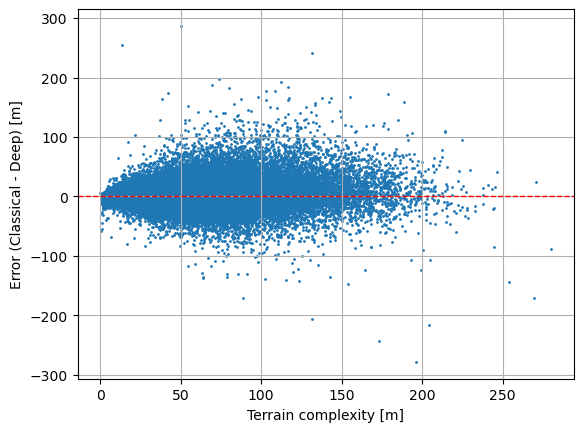

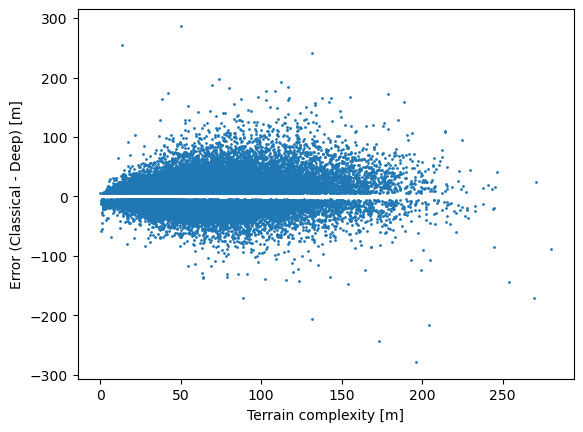

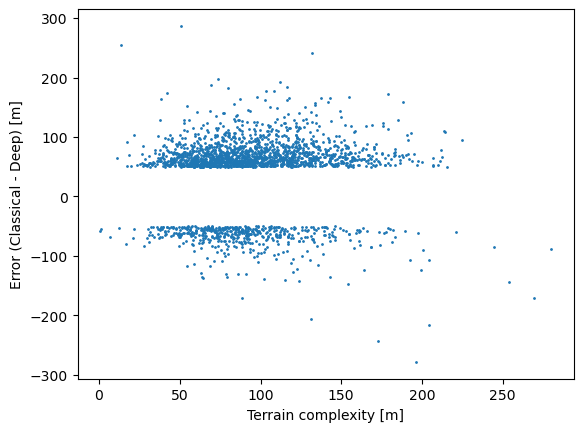

In [26]:
from matplotlib.colors import Normalize, TwoSlopeNorm

# -------------------------------------
# PICK QUERY SAMPLE
# -------------------------------------
#i = np.random.randint(len(testset))  # random query from test
test_err = test_pred - test_true
test_err_classical = test_pred_unnorm_classical - test_true_unnorm

vec= np.abs(test_err_classical) -np.abs(test_err) 

Terrain_complexity = np.std(testset.obs_y.numpy(), axis=1)
print(Terrain_complexity)
diff = testset.obs_coords - testset.query_coords.unsqueeze(1)  # (N, K, 2)
nei_dists = torch.norm(diff, dim=2)  # (N, K)
mean_neighbor_dist = nei_dists.mean(dim=1).cpu().numpy()  # (N,)

# plot the error vs the terrain complexity
import matplotlib.pyplot as plt
plt.figure()
plt.scatter(Terrain_complexity, vec, s=1)
plt.xlabel("Terrain complexity [m]")
plt.ylabel("Error (Classical - Deep) [m]")
plt.grid(True)
plt.axhline(0, color='red', linestyle='--', linewidth=1)

mask = (vec  > 5) | (vec < -5)
vec_masked = vec[mask]
Terrain_complexity_masked = Terrain_complexity[mask]
plt.figure()
plt.scatter(Terrain_complexity_masked, vec_masked, s=1)
plt.xlabel("Terrain complexity [m]")
plt.ylabel("Error (Classical - Deep) [m]")

mask = (vec  > 50) | (vec < -50)
vec_masked = vec[mask]
Terrain_complexity_masked = Terrain_complexity[mask]
plt.figure()
plt.scatter(Terrain_complexity_masked, vec_masked, s=1)
plt.xlabel("Terrain complexity [m]")
plt.ylabel("Error (Classical - Deep) [m]")



In [28]:
print(np.std(np.array([2788, 2633, 2742, 2748, 2416, 2148, 2805, 2748, 2542, 2687])))
print(np.mean(np.array([ 2788, 2633, 2742, 2748, 2416, 2148, 2805, 2748, 2542, 2687])))

196.19329754097103
2625.7
